# 🌱 Soil Classification with MobileNetV2 Transfer Learning

This notebook trains a deep learning model to classify soil images into **7 categories** using transfer learning on top of MobileNetV2, a lightweight CNN pre-trained on ImageNet.

**Dataset:** [Comprehensive Soil Classification Datasets](https://www.kaggle.com/datasets/ai4a-lab/comprehensive-soil-classification-datasets) via KaggleHub  
**Classes:** Alluvial, Arid, Black, Laterite, Mountain, Red, Yellow Soil  
**Framework:** TensorFlow / Keras

---
### Pipeline Overview
1. Environment & GPU check
2. Imports
3. Dataset download & loading
4. Data augmentation
5. Model architecture (transfer learning)
6. Initial training (head only)
7. Fine-tuning (unfreeze top layers)
8. Training history visualization
9. Evaluation — classification report & confusion matrix
10. Export to `.h5`
11. Export to `.tflite` (quantized, edge-ready)

## 0. Environment Setup

Before anything else, we apply a **four-layer log suppression strategy** to silence all non-essential output:
- `TF_CPP_MIN_LOG_LEVEL=3` — suppresses TensorFlow's C++ runtime messages at the OS level
- `ABSL_MIN_LOG_LEVEL=3` — suppresses absl-py messages at the OS level (covers TFLite conversion spam)
- `tf.get_logger().setLevel('ERROR')` — suppresses Python-level TF logs including the TFLite `while_loop` conversion warnings
- `absl.logging.set_verbosity(ERROR)` — suppresses absl-level warnings like "Found untraced functions"

We then verify the runtime environment and check whether a CUDA-capable GPU is available. If found, we enable **memory growth** so TensorFlow allocates GPU memory incrementally rather than reserving it all upfront — this prevents OOM errors when running alongside other processes.

In [1]:
# --- 0. Suppress Warnings ---
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TF C++ logs (0=all, 1=info, 2=warn, 3=error)
os.environ['ABSL_MIN_LOG_LEVEL'] = '3'    # Suppress absl-py logs (covers TFLite conversion spam)
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings('ignore')

# Check Environment Configuration
import tensorflow as tf
import sys
import absl.logging

# Suppress TF Python-level logs and absl logs (kills TFLite while_loop warnings & untraced functions)
tf.get_logger().setLevel('ERROR')
absl.logging.set_verbosity(absl.logging.ERROR)

print(f"Python: {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")

# List all physical devices
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print(f"\nCPUs available: {len(cpus)}")
print(f"GPUs available: {len(gpus)}")

if gpus:
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu.name}")
        details = tf.config.experimental.get_device_details(gpu)
        if details:
            print(f"         {details}")
    # Enable memory growth to avoid allocating all GPU memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("\n\u2705 GPU is available! TensorFlow will use GPU for training.")
else:
    print("\n\u26a0\ufe0f No GPU detected. TensorFlow will use CPU only.")
    print("   For GPU support, install CUDA 11.2 + cuDNN 8.1")

Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
TensorFlow: 2.10.1
Built with CUDA: True

CPUs available: 1
GPUs available: 1
  GPU 0: /physical_device:GPU:0
         {'device_name': 'NVIDIA GeForce RTX 4060', 'compute_capability': (8, 9)}

✅ GPU is available! TensorFlow will use GPU for training.


## 1. Imports

We import all required libraries:
- **NumPy / Pandas** — numerical operations and data handling
- **Matplotlib / Seaborn** — plotting training curves and the confusion matrix
- **TensorFlow / Keras** — model building, training, and export
- **scikit-learn** — classification report and confusion matrix utilities
- **kagglehub** — programmatic dataset download from Kaggle

Random seeds are fixed at `42` for reproducibility across runs.

In [2]:
# --- 1. Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models, applications, callbacks, optimizers
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

import kagglehub

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

## 2. Dataset Download

We download the **Comprehensive Soil Classification Dataset** from Kaggle using `kagglehub`. The dataset contains 1,187 labelled images across 7 soil classes stored under the `Orignal-Dataset/` subdirectory.

> **Note:** KaggleHub caches downloaded datasets locally, so subsequent runs won't re-download.

In [3]:
# --- 2. Dataset Setup ---
print("Downloading dataset...")
path = kagglehub.dataset_download("ai4a-lab/comprehensive-soil-classification-datasets")

original_dataset_path = os.path.join(path, "Orignal-Dataset")

if not os.path.exists(original_dataset_path):
    print(f"ERROR: Could not find path {original_dataset_path}")
else:
    print(f"Dataset located at {original_dataset_path}")

Dataset located at C:\Users\samar\.cache\kagglehub\datasets\ai4a-lab\comprehensive-soil-classification-datasets\versions\1\Orignal-Dataset


## 3. Data Pipeline & Preprocessing

Images are loaded using `image_dataset_from_directory`, which automatically infers class labels from folder names.

**Split strategy:**
- 80% → training (`950` images)
- The remaining 20% (`237` images) is further split 50/50 into validation and test sets

All images are resized to **224×224** pixels — the input size expected by MobileNetV2.

**Performance optimizations:**
- `.cache()` — keeps the dataset in memory after the first epoch, eliminating repeated disk reads
- `.shuffle(1000)` — randomizes sample order each epoch to reduce ordering bias
- `.prefetch(AUTOTUNE)` — overlaps data preprocessing with model training to keep the GPU fed

In [4]:
# --- 3. Data Pipeline & Preprocessing ---
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Standard size for MobileNetV2

print("Loading Training Dataset...")
train_ds = image_dataset_from_directory(
    original_dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

print("Loading Validation Dataset...")
val_ds_raw = image_dataset_from_directory(
    original_dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
print(f"\nDetected {len(class_names)} classes: {class_names}")

# Split the validation set into 50% validation and 50% test
val_batches = tf.data.experimental.cardinality(val_ds_raw)
val_ds = val_ds_raw.take(val_batches // 2)
test_ds = val_ds_raw.skip(val_batches // 2)

# Optimize dataset loading performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Loading Training Dataset...
Found 1187 files belonging to 7 classes.
Using 950 files for training.
Loading Validation Dataset...
Found 1187 files belonging to 7 classes.
Using 237 files for validation.

Detected 7 classes: ['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']


## 4. Data Augmentation

With only ~950 training images, the model is at serious risk of overfitting. A more aggressive augmentation pipeline is applied to synthetically increase the effective diversity of the training set:

| Transform | Range | Rationale |
|-----------|-------|-----------|
| `RandomFlip` | H + V | Soil textures have no canonical orientation |
| `RandomRotation` | ±30% | Wider angle range vs original ±20% |
| `RandomZoom` | ±15% | Simulates varying camera-to-ground distance |
| `RandomContrast` | ±20% | Accounts for shadow and saturation differences |
| `RandomBrightness` | ±20% | **New** — handles indoor vs outdoor lighting variation |
| `RandomTranslation` | ±10% H&V | **New** — simulates off-centre framing |

All transforms are applied **only during training** and are disabled during validation and inference.

In [5]:
# --- 4. Data Augmentation ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),       # Soil textures are orientation-invariant
    layers.RandomRotation(0.3),                          # ±30% rotation for wider angle coverage
    layers.RandomZoom(0.15),                             # ±15% zoom for camera distance variation
    layers.RandomContrast(0.2),                          # ±20% contrast for lighting variation
    layers.RandomBrightness(0.2),                        # ±20% brightness for outdoor/indoor lighting
    layers.RandomTranslation(height_factor=0.1,          # ±10% vertical shift
                              width_factor=0.1),          # ±10% horizontal shift
], name="data_augmentation")

## 5. Model Architecture — MobileNetV2 Transfer Learning

We use **MobileNetV2** pre-trained on ImageNet as a frozen feature extractor. Its depthwise separable convolutions make it significantly lighter than standard CNNs while still encoding rich visual features (edges, textures, shapes) that transfer well to soil images.

**Upgraded 3-block classification head:**

| Layer | Details | Purpose |
|-------|---------|--------|
| `GlobalAveragePooling2D` | — | Collapses spatial maps to a 1D vector |
| `Dense(256)` + `BatchNorm` + `Dropout(0.4)` | L2=1e-4 | Broad feature combination; BN accelerates convergence |
| `Dense(128)` + `BatchNorm` + `Dropout(0.3)` | L2=1e-4 | Mid-level soil-specific pattern refinement |
| `Dense(64)` + `Dropout(0.2)` | L2=1e-4 | Final feature compression before classification |
| `Dense(7, softmax)` | — | One neuron per soil class |

**Why these changes improve accuracy:**
- **BatchNormalization** normalizes layer activations between mini-batches, dramatically stabilizing gradients and allowing higher learning rates in Phase 1
- **L2 regularization** penalizes large weights, preventing the head from memorizing training samples
- **3 dense blocks** (vs 1 previously) give the network more representational capacity to separate 7 visually similar soil classes
- **Tapering dropout** (0.4 → 0.3 → 0.2) applies strongest regularization where the feature space is widest

The base model is **frozen** during Phase 1 so only the head learns.

In [6]:
# --- 5. Model Architecture (MobileNetV2 Transfer Learning) ---
from tensorflow.keras import regularizers

base_model = applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)

# --- Upgraded Classification Head ---
x = layers.GlobalAveragePooling2D()(x)

# Block 1: 256-unit dense + BN + Dropout — learns broad soil feature combinations
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)    # Normalizes activations → faster convergence, less internal covariate shift
x = layers.Dropout(0.4)(x)

# Block 2: 128-unit dense + BN + Dropout — refines into mid-level discriminative features
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Block 3: 64-unit dense + Dropout — final feature compression before classification
x = layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)

# Output layer
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

def sparse_crossentropy_label_smoothed(y_true, y_pred, smoothing=0.1):
    n_classes = tf.cast(tf.shape(y_pred)[-1], tf.float32)
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)  # flatten (None,1) → (None,)
    y_true_onehot = tf.one_hot(y_true, tf.shape(y_pred)[-1])
    y_true_smooth = y_true_onehot * (1.0 - smoothing) + (smoothing / n_classes)
    return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=sparse_crossentropy_label_smoothed,
    metrics=['accuracy']
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                      

## 6. Phase 1 — Training the Classification Head

In the first training phase, **only the custom head is trained** while the MobileNetV2 base remains frozen. This lets the randomly-initialized dense layers converge to reasonable weights before we start nudging the base model's carefully pre-trained features.

**Callbacks:**
- `EarlyStopping(patience=10)` — stops training if validation loss stagnates for 10 epochs and restores the best checkpoint automatically
- `ReduceLROnPlateau(patience=5, factor=0.2)` — cuts the learning rate by 80% when val loss plateaus, allowing finer convergence

Training is capped at **30 epochs** (up from 20) — the added BatchNormalization layers stabilize gradients and allow the model to continue improving further into training.

In [7]:
# --- 6. Initial Training Phase (Head Only) ---
print("Starting Initial Training Phase (Training classification head only)...")

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1, min_lr=1e-6)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,   # Increased from 20 — BatchNorm heads typically need more epochs to fully converge
    callbacks=callbacks_list
)

Starting Initial Training Phase (Training classification head only)...
Epoch 1/30
30/30 [==============================] - 33s 705ms/step - loss: 1.9667 - accuracy: 0.3905 - val_loss: 1.3610 - val_accuracy: 0.6875 - lr: 0.0010
Epoch 2/30
30/30 [==============================] - 20s 659ms/step - loss: 1.3503 - accuracy: 0.6421 - val_loss: 1.2430 - val_accuracy: 0.6797 - lr: 0.0010
Epoch 3/30
30/30 [==============================] - 20s 691ms/step - loss: 1.2025 - accuracy: 0.7147 - val_loss: 1.1902 - val_accuracy: 0.7031 - lr: 0.0010
Epoch 4/30
30/30 [==============================] - 21s 700ms/step - loss: 1.1740 - accuracy: 0.7347 - val_loss: 1.1406 - val_accuracy: 0.7500 - lr: 0.0010
Epoch 5/30
30/30 [==============================] - 21s 702ms/step - loss: 1.1143 - accuracy: 0.7358 - val_loss: 1.1308 - val_accuracy: 0.7109 - lr: 0.0010
Epoch 6/30
30/30 [==============================] - 21s 703ms/step - loss: 1.0741 - accuracy: 0.7726 - val_loss: 1.1657 - val_accuracy: 0.7344 - lr: 

## 7. Phase 2 — Fine-Tuning the Top Layers

Once the head has converged, we unfreeze MobileNetV2 **from layer 80 onward** (previously layer 100) for fine-tuning. This exposes more high-level feature layers to task-specific gradient updates while keeping the generic low-level feature detectors (edges, textures in layers 0–79) frozen.

**Key changes for fine-tuning:**
- **Unfreeze from layer 80** (not 100) — ~34 additional convolutional layers now adapt to soil-specific patterns
- **BN layers kept frozen** — the base model's BatchNorm statistics are preserved; updating them on a small dataset can destabilize training
- **Learning rate `5e-5`** — slightly higher than the original `1e-5` to speed adaptation of the extra layers, but still conservative enough to protect pre-trained weights
- **20 epochs** — gives the additional unfrozen layers enough iterations to converge

In [8]:
# --- 7. Fine-Tuning Phase (Unfreeze Top Layers) ---
print("\nStarting Fine-Tuning Phase...")

base_model.trainable = True
# Revert to layer 100 — layer 80 was too aggressive given the custom loss scale
for layer in base_model.layers[:100]:
    layer.trainable = False

# Keep base model's BN layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # back to 1e-5 — 5e-5 was destroying pre-trained weights
    loss=sparse_crossentropy_label_smoothed,
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_list
)


Starting Fine-Tuning Phase...
Epoch 1/20
30/30 [==============================] - 29s 703ms/step - loss: 0.8272 - accuracy: 0.8832 - val_loss: 1.0396 - val_accuracy: 0.7969 - lr: 1.0000e-05
Epoch 2/20
30/30 [==============================] - 21s 688ms/step - loss: 0.8185 - accuracy: 0.8832 - val_loss: 0.9763 - val_accuracy: 0.8203 - lr: 1.0000e-05
Epoch 3/20
30/30 [==============================] - 20s 676ms/step - loss: 0.8092 - accuracy: 0.8937 - val_loss: 0.9973 - val_accuracy: 0.8359 - lr: 1.0000e-05
Epoch 4/20
30/30 [==============================] - 20s 674ms/step - loss: 0.8043 - accuracy: 0.8937 - val_loss: 1.0055 - val_accuracy: 0.7969 - lr: 1.0000e-05
Epoch 5/20
30/30 [==============================] - 20s 676ms/step - loss: 0.7815 - accuracy: 0.9168 - val_loss: 0.9943 - val_accuracy: 0.8203 - lr: 1.0000e-05
Epoch 6/20
30/30 [==============================] - 20s 678ms/step - loss: 0.7865 - accuracy: 0.9063 - val_loss: 0.9748 - val_accuracy: 0.8438 - lr: 1.0000e-05
Epoch 7/2

## 8. Training History Visualization

We concatenate the loss and accuracy histories from both training phases and plot them together. A **vertical dashed line** marks the transition from Phase 1 (head-only) to Phase 2 (fine-tuning), making it easy to see the impact of unlocking the base model's top layers.

Ideally, you should observe:
- Training and validation accuracy tracking closely (no significant overfitting gap)
- A further accuracy boost after the fine-tuning transition

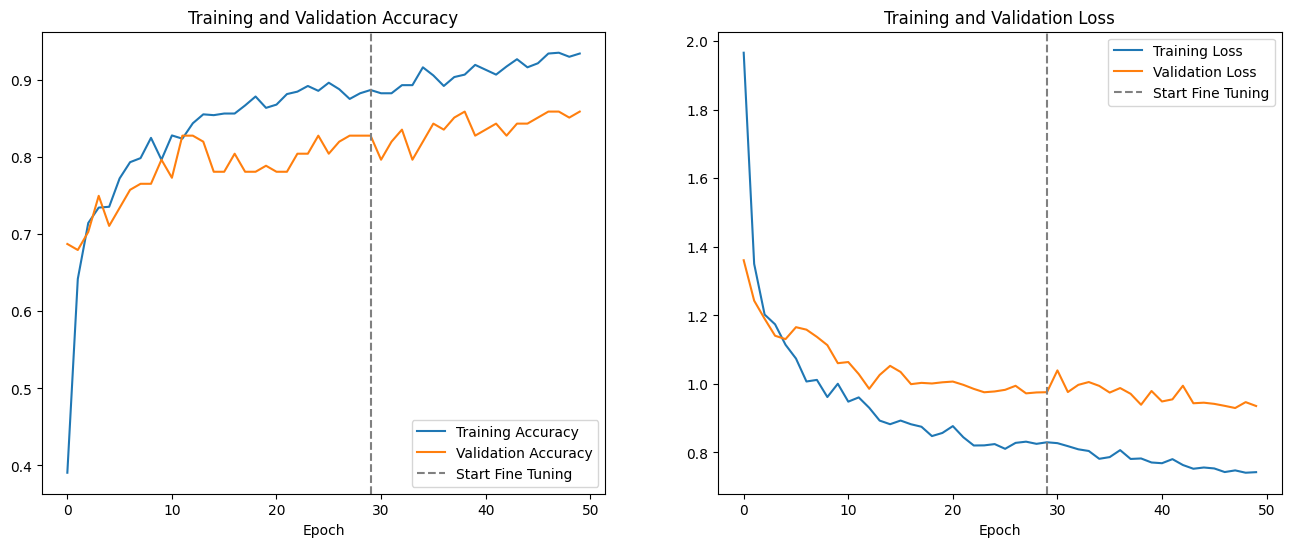

In [9]:
# --- 8. Visualizing Training History ---
# Combine histories
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=len(history.history['accuracy'])-1, color='gray', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=len(history.history['loss'])-1, color='gray', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')

plt.show()

## 9. Evaluation — Classification Report & Confusion Matrix

We evaluate the final model on the **held-out test set** (never seen during training or validation).

- **Classification Report** — shows per-class precision, recall, and F1-score. Useful for identifying which soil types are hardest to distinguish.
- **Confusion Matrix** — a heatmap showing where the model confuses one class for another. Off-diagonal cells with high counts indicate visually similar soil pairs that may benefit from more training data or targeted augmentation.

Evaluating on Test Dataset...
4/4 [==============================] - 0s 31ms/step - loss: 0.9101 - accuracy: 0.8807

Test Accuracy: 88.07%

Generating Classification Report and Confusion Matrix...

Classification Report:
               precision    recall  f1-score   support

Alluvial_Soil       1.00      0.33      0.50         6
    Arid_Soil       0.92      0.92      0.92        24
   Black_Soil       1.00      1.00      1.00        21
Laterite_Soil       0.68      0.89      0.77        19
Mountain_Soil       0.86      0.95      0.90        19
     Red_Soil       1.00      0.85      0.92        13
  Yellow_Soil       1.00      0.71      0.83         7

     accuracy                           0.88       109
    macro avg       0.92      0.81      0.83       109
 weighted avg       0.90      0.88      0.88       109



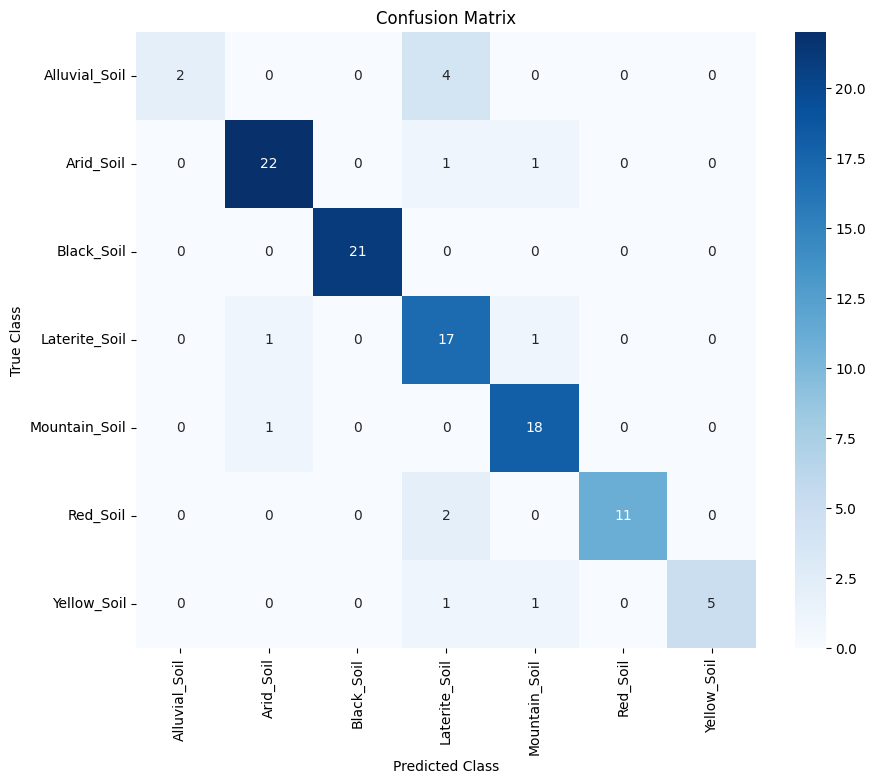

In [10]:
# --- 9. Evaluation & Metrics ---
print("Evaluating on Test Dataset...")
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

y_true = []
y_pred = []

print("\nGenerating Classification Report and Confusion Matrix...")
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

## 10. Export Model — `.h5` Format

We save the full trained model (architecture + weights + optimizer state) in the legacy Keras HDF5 format (`.h5`). This file can be reloaded with `tf.keras.models.load_model()` for further training or inference in Python environments.

> The resulting `.h5` file is approximately **25 MB** — suitable for server-side or desktop deployment, but too large for most mobile or embedded targets (see TFLite export below).

In [11]:
# --- 10. Export Model (H5) ---
model_path = "../models/soil_classification_mobilenetv2.h5"
model.save(model_path)
print(f"\nModel successfully saved to {model_path}")


Model successfully saved to ../models/soil_classification_mobilenetv2.h5


## 11. Export to TFLite — Edge / Mobile Deployment

For deployment on resource-constrained devices (Android, Raspberry Pi, microcontrollers), we convert the model to **TensorFlow Lite** format with **dynamic range quantization**.

Quantization reduces model size and inference latency by converting 32-bit floating point weights to 8-bit integers, with minimal accuracy loss in practice.

**Result:**
| Format | Size |
|--------|------|
| `.h5` (full) | ~25 MB |
| `.tflite` (quantized) | ~2.5 MB |

A **~10× size reduction** makes the model viable for on-device inference — for example, a smartphone app that classifies soil from a camera image in the field.

In [12]:
# --- 11. Convert and Export to TFLite (For Edge/Mobile) ---
import io, contextlib

print("Converting model to TensorFlow Lite format...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Suppress TFLite while_loop conversion warnings (they are non-fatal and expected for augmentation layers)
with contextlib.redirect_stderr(io.StringIO()):
    tflite_model = converter.convert()

tflite_model_path = "../models/soil_classification_mobilenetv2.tflite"
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"\nTFLite model successfully saved to {tflite_model_path}")

h5_size = os.path.getsize(model_path) / (1024 * 1024)
tflite_size = os.path.getsize(tflite_model_path) / (1024 * 1024)
print(f"\nModel Sizes:\n - H5: {h5_size:.2f} MB\n - TFLite (Quantized): {tflite_size:.2f} MB")
print("\nReady for edge deployment!")

Converting model to TensorFlow Lite format...

TFLite model successfully saved to ../models/soil_classification_mobilenetv2.tflite

Model Sizes:
 - H5: 27.28 MB
 - TFLite (Quantized): 2.75 MB

Ready for edge deployment!
